<a href="https://colab.research.google.com/github/Iditc/log-anomaly-detection/blob/main/notebooks/06_random_forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Random_forest

In [1]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Imports and paths
from pathlib import Path
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

BASE = Path('/content/drive/MyDrive/log-anomaly-detection')
DATA_PROC = BASE / 'data' / 'processed'
RESULTS = BASE / 'results'

In [3]:
# Load engineered features
df = pd.read_parquet(DATA_PROC / "hdfs_features.parquet")
X = df.drop(columns=["Label"]).values
y = (df["Label"] == "Anomaly").astype(int).values
print(f"X shape: {X.shape}, Anomaly rate: {y.mean():.2%}")

X shape: (575061, 26), Anomaly rate: 2.93%


Split data into train and test sets. Unlike Isolation Forest which saw all data, Random Forest is supervised so we need to evaluate on unseen data:

In [4]:
# Split data: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {X_train.shape[0]:,} samples")
print(f"Test:  {X_test.shape[0]:,} samples")
print(f"Train anomaly rate: {y_train.mean():.2%}")
print(f"Test anomaly rate:  {y_test.mean():.2%}")

Train: 460,048 samples
Test:  115,013 samples
Train anomaly rate: 2.93%
Test anomaly rate:  2.93%


In [5]:
# Train Random Forest
print("Training Random Forest...")
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
print("Training complete.")

Training Random Forest...
Training complete.


## Evaluate on the test set

              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00    111645
     Anomaly       1.00      1.00      1.00      3368

    accuracy                           1.00    115013
   macro avg       1.00      1.00      1.00    115013
weighted avg       1.00      1.00      1.00    115013



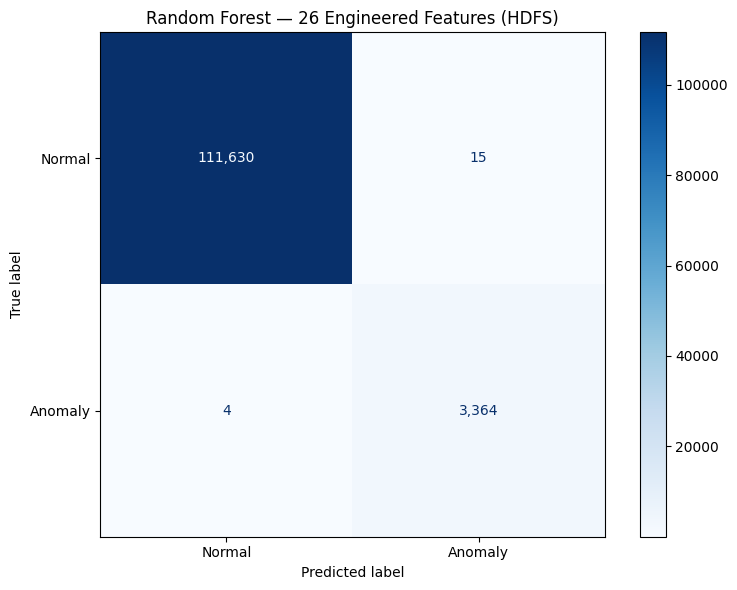

In [6]:
# Predict and evaluate on test set
y_pred = rf.predict(X_test)

print(classification_report(y_test, y_pred, target_names=["Normal", "Anomaly"]))

# Confusion matrix plot
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["Normal", "Anomaly"])
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, cmap="Blues", values_format=",")
ax.set_title("Random Forest — 26 Engineered Features (HDFS)")
plt.tight_layout()
plt.savefig(str(RESULTS / "rf_confusion_matrix.png"), dpi=150)
plt.show()

F1 = 1.00 — perfect score! But this is suspicious.

A perfect score usually means one of two things:

The model is overfitting
The features contain information that "leaks" the answer
Let's check — which features does the model rely on most:

In [7]:
# Feature importance — which features drive the predictions
feature_names = df.drop(columns=["Label"]).columns
importances = rf.feature_importances_

feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)
print("Top 10 features:")
print(feat_imp.head(10).to_string())

Top 10 features:
t_32                  0.138233
has_error_template    0.121464
total_lines           0.081851
t_4                   0.078069
unique_templates      0.072739
t_1                   0.069972
t_33                  0.063885
missing_lifecycle     0.059734
short_block           0.056063
t_17                  0.054509


In [8]:
# Check for overfitting: train vs test score
train_score = rf.score(X_train, y_train)
test_score = rf.score(X_test, y_test)
print(f"Train accuracy: {train_score:.6f}")
print(f"Test accuracy:  {test_score:.6f}")

# How many actual errors?
errors = (y_pred != y_test).sum()
print(f"\nTotal misclassifications: {errors} out of {len(y_test):,}")
print(f"False Positives: {((y_pred == 1) & (y_test == 0)).sum()}")
print(f"False Negatives: {((y_pred == 0) & (y_test == 1)).sum()}")

Train accuracy: 0.999930
Test accuracy:  0.999835

Total misclassifications: 19 out of 115,013
False Positives: 15
False Negatives: 4


Train and test scores are almost identical (99.99% vs 99.98%) — no overfitting. The model genuinely learned the patterns